# PEC Quantitative Analysis — Flow Measurements

**Goal:** CNN-based phase error correction (PEC) recovers flow measurements that
agree with manually corrected ground truth, and represents a significant
improvement over leaving the data uncorrected.

This notebook evaluates two claims:
1. **CNN-corrected flow agrees with manual correction** — low bias and tight limits of agreement.
2. **CNN correction reduces error vs. uncorrected data** — absolute and relative errors are smaller.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy import stats as sp_stats

NOTEBOOK_DIR = Path.home() / "vascular-superenhancement-4d-flow" / "notebooks" / "analysis" / "PEC_quantitative_analysis"
DATA_CSV = NOTEBOOK_DIR / "consolidated.csv"
ERROR_CSV = NOTEBOOK_DIR / "error_metrics.csv"

COLORS = {"uncorrected": "white", "cnn": "black", "manual": "#888888"}
LABELS = {"uncorrected": "Uncorrected", "cnn": "CNN Corrected", "manual": "Manual"}
VESSELS = ["Ao", "PA"]
VESSEL_LABELS = {"Ao": "Aorta", "PA": "Pulmonary Artery"}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
})

BOXPLOT_KW = dict(
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="#333",
                   markersize=5, zorder=5),
    boxprops=dict(linewidth=1.2, edgecolor="#333"),
    whiskerprops=dict(linewidth=1.0, linestyle="-"),
    capprops=dict(linewidth=1.0),
    medianprops=dict(color="#2d2d2d", linewidth=1.5),
    flierprops=dict(marker="o", markerfacecolor="none", markeredgecolor="#888",
                    markersize=5, alpha=0.7),
)

def color_boxes(bp, colors):
    for box, c in zip(bp["boxes"], colors):
        box.set_facecolor(c)
        box.set_alpha(0.85)

data = pd.read_csv(DATA_CSV)
compared = pd.read_csv(ERROR_CSV)

print(f"{len(data)} rows  |  {data['patient'].nunique()} patients  |  "
      f"vessels: {sorted(data['vessel'].unique())}  |  methods: {sorted(data['method'].unique())}")
print(f"{len(compared)} comparison rows")

90 rows  |  15 patients  |  vessels: ['Ao', 'PA']  |  methods: ['cnn', 'manual', 'uncorrected']
60 comparison rows


## Pivot for paired analysis

Create wide-format tables for direct paired comparisons.

In [2]:
flow_pivot = data.pivot_table(
    index=["patient", "vessel"],
    columns="method",
    values="flow",
).reset_index()

flow_pivot["cnn_error"] = flow_pivot["cnn"] - flow_pivot["manual"]
flow_pivot["uncorrected_error"] = flow_pivot["uncorrected"] - flow_pivot["manual"]
flow_pivot["cnn_abs_error"] = flow_pivot["cnn_error"].abs()
flow_pivot["uncorrected_abs_error"] = flow_pivot["uncorrected_error"].abs()
flow_pivot["cnn_pct_error"] = (flow_pivot["cnn_error"] / flow_pivot["manual"]) * 100
flow_pivot["uncorrected_pct_error"] = (flow_pivot["uncorrected_error"] / flow_pivot["manual"]) * 100

flow_pivot = flow_pivot.dropna(subset=["manual"])

print(f"{len(flow_pivot)} patient-vessel pairs with complete data")
flow_pivot.head()

29 patient-vessel pairs with complete data


method,patient,vessel,cnn,manual,uncorrected,cnn_error,uncorrected_error,cnn_abs_error,uncorrected_abs_error,cnn_pct_error,uncorrected_pct_error
0,Balboloop,Ao,6.73,6.32,6.92,0.41,0.60,0.41,0.60,6.487342,9.493671
1,Balboloop,PA,6.61,6.52,7.63,0.09,1.11,0.09,1.11,1.380368,17.024540
2,Biswifo,Ao,5.66,5.67,6.91,-0.01,1.24,0.01,1.24,-0.176367,21.869489
3,Biswifo,PA,5.70,5.91,5.05,-0.21,-0.86,0.21,0.86,-3.553299,-14.551607
4,Bomatog,Ao,6.91,7.53,6.74,-0.62,-0.79,0.62,0.79,-8.233732,-10.491368


## Statistical tests

For each vessel:
1. **CNN vs Manual** — paired t-test and Wilcoxon signed-rank on flow values (bias test)
2. **CNN abs error vs Uncorrected abs error** — paired t-test and Wilcoxon signed-rank (error reduction test)
3. **Correlation**: Pearson r between CNN and Manual, Uncorrected and Manual

In [3]:
def _sig(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "ns"

stat_rows = []

for vessel in VESSELS:
    vp = flow_pivot[flow_pivot["vessel"] == vessel].dropna(subset=["manual", "cnn", "uncorrected"])
    n = len(vp)

    # --- Bias tests: is method flow different from manual? ---
    for method in ["cnn", "uncorrected"]:
        diff = vp[f"{method}_error"].values
        shapiro_stat, shapiro_p = sp_stats.shapiro(diff)
        t_stat, t_p = sp_stats.ttest_rel(vp[method].values, vp["manual"].values)
        w_stat, w_p = sp_stats.wilcoxon(diff)
        r, r_p = sp_stats.pearsonr(vp[method].values, vp["manual"].values)

        mae = vp[f"{method}_abs_error"].mean()
        rmse = np.sqrt((diff ** 2).mean())

        stat_rows.append({
            "vessel": vessel,
            "comparison": f"{LABELS[method]} vs Manual",
            "n": n,
            "bias": diff.mean(),
            "bias_std": diff.std(),
            "loa_lower": diff.mean() - 1.96 * diff.std(),
            "loa_upper": diff.mean() + 1.96 * diff.std(),
            "mae": mae,
            "rmse": rmse,
            "pearson_r": r,
            "pearson_p": r_p,
            "shapiro_p": shapiro_p,
            "ttest_p": t_p,
            "wilcoxon_p": w_p,
        })

    # --- Error reduction test: is CNN abs error < Uncorrected abs error? ---
    cnn_ae = vp["cnn_abs_error"].values
    unc_ae = vp["uncorrected_abs_error"].values
    error_diff = unc_ae - cnn_ae

    t_stat_er, t_p_er = sp_stats.ttest_rel(unc_ae, cnn_ae)
    w_stat_er, w_p_er = sp_stats.wilcoxon(error_diff)

    stat_rows.append({
        "vessel": vessel,
        "comparison": "Error reduction (|Uncorr| − |CNN|)",
        "n": n,
        "bias": error_diff.mean(),
        "bias_std": error_diff.std(),
        "loa_lower": np.nan,
        "loa_upper": np.nan,
        "mae": np.nan,
        "rmse": np.nan,
        "pearson_r": np.nan,
        "pearson_p": np.nan,
        "shapiro_p": sp_stats.shapiro(error_diff)[1],
        "ttest_p": t_p_er,
        "wilcoxon_p": w_p_er,
    })

stats_results = pd.DataFrame(stat_rows)
stats_results["wilcoxon_sig"] = stats_results["wilcoxon_p"].apply(_sig)
stats_results["ttest_sig"] = stats_results["ttest_p"].apply(_sig)
stats_results["normality"] = stats_results["shapiro_p"].apply(lambda p: "yes" if p > 0.05 else "no")

display(stats_results.round(4))

,vessel,comparison,n,bias,bias_std,loa_lower,loa_upper,mae,rmse,pearson_r,pearson_p,shapiro_p,ttest_p,wilcoxon_p,wilcoxon_sig,ttest_sig,normality
0,Ao,CNN Corrected vs Manual,15,0.1820,0.4233,-0.6477,1.0117,0.3460,0.4608,0.9647,0.0000,0.6839,0.1300,0.1876,ns,ns,yes
1,Ao,Uncorrected vs Manual,15,0.7640,0.8904,-0.9812,2.5092,1.0507,1.1732,0.8591,0.0000,0.2548,0.0063,0.0084,**,**,yes
2,Ao,Error reduction (|Uncorr| − |CNN|),15,0.7047,0.6050,NaN,NaN,NaN,NaN,NaN,NaN,0.6674,0.0007,0.0012,**,***,yes
3,PA,CNN Corrected vs Manual,14,0.1786,0.7465,-1.2846,1.6417,0.5414,0.7676,0.9531,0.0000,0.4695,0.4041,0.3276,ns,ns,yes
4,PA,Uncorrected vs Manual,14,0.4536,1.2884,-2.0717,2.9789,1.2193,1.3659,0.7600,0.0016,0.0587,0.2266,0.2166,ns,ns,yes
5,PA,Error reduction (|Uncorr| − |CNN|),14,0.6779,0.7503,NaN,NaN,NaN,NaN,NaN,NaN,0.9224,0.0062,0.0085,**,**,yes


---

# 1. Primary result: CNN-corrected flow agrees with manual correction

### 1a. Bland-Altman plots

Difference (method − manual) vs. mean of the two, for both CNN and Uncorrected.
Tighter limits of agreement indicate better agreement.

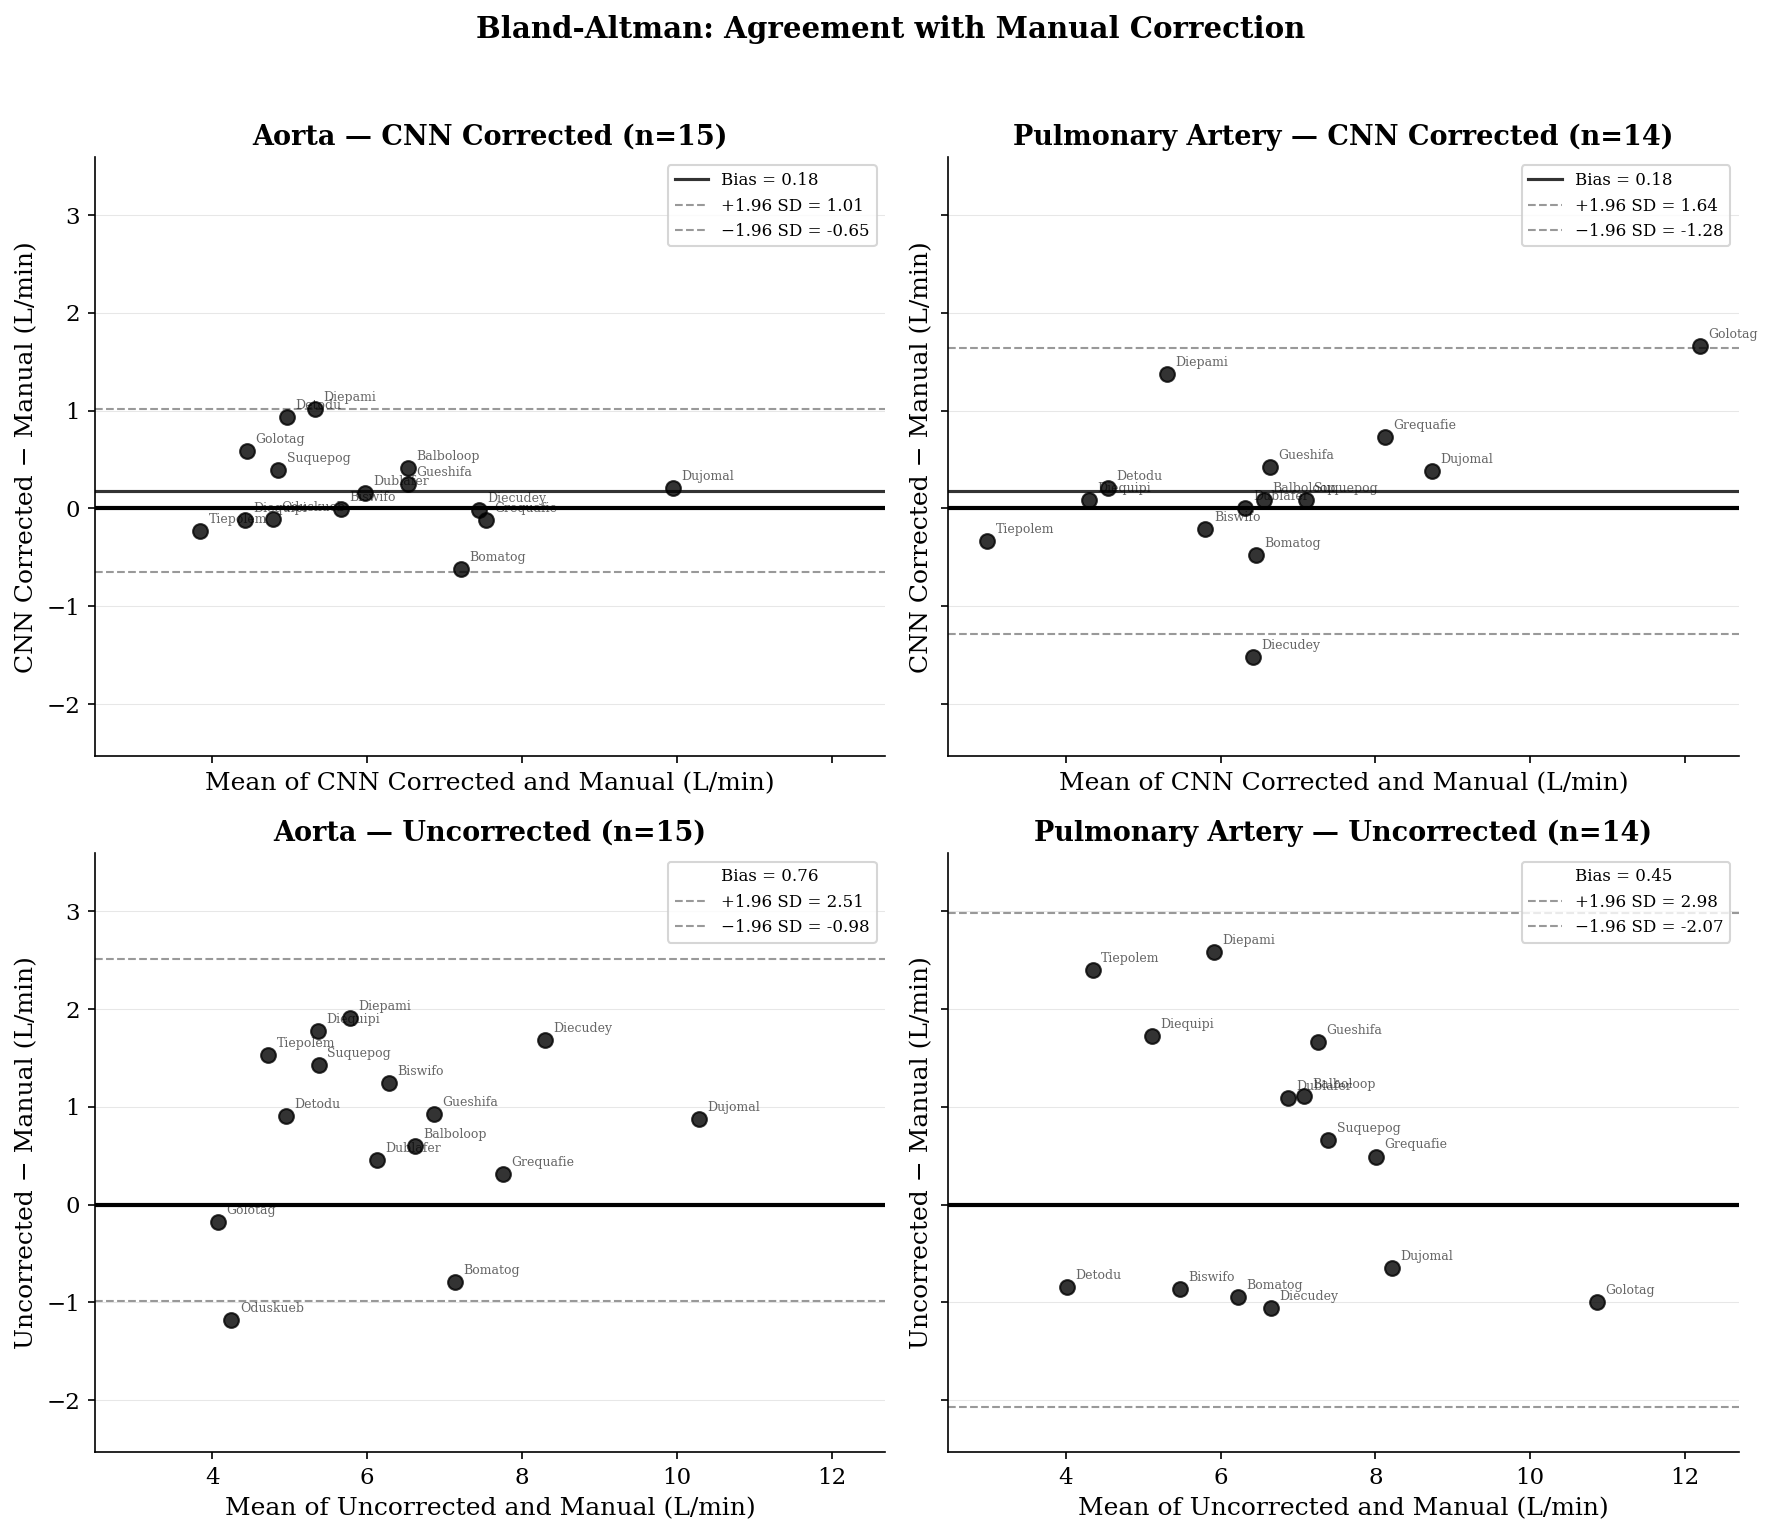

In [4]:
def bland_altman(ax, method_vals, ref_vals, color, label, patient_labels=None, x_lo=None, x_hi=None):
    """Draw a Bland-Altman plot on the given axes."""
    mean_vals = (method_vals + ref_vals) / 2
    diff_vals = method_vals - ref_vals

    bias = diff_vals.mean()
    sd = diff_vals.std()
    loa_upper = bias + 1.96 * sd
    loa_lower = bias - 1.96 * sd

    ax.scatter(mean_vals, diff_vals, c="black", edgecolors="black", s=50, alpha=0.8, zorder=3)
    ax.axhline(bias, color=color, linewidth=1.5, linestyle="-", alpha=0.8,
               label=f"Bias = {bias:.2f}")
    ax.axhline(loa_upper, color="#555", linewidth=1.0, linestyle="--", alpha=0.6,
               label=f"+1.96 SD = {loa_upper:.2f}")
    ax.axhline(loa_lower, color="#555", linewidth=1.0, linestyle="--", alpha=0.6,
               label=f"−1.96 SD = {loa_lower:.2f}")
    ax.axhline(0, color="black", linewidth=2.0, alpha=1.0)
    if x_lo is not None and x_hi is not None:
        ax.fill_between([x_lo, x_hi], loa_lower, loa_upper, color="#cccccc", alpha=0.15)

    if patient_labels is not None:
        for x, y, pt in zip(mean_vals, diff_vals, patient_labels):
            ax.annotate(pt, (x, y), fontsize=6, alpha=0.6, xytext=(4, 4),
                        textcoords="offset points")

    ax.set_xlabel(f"Mean of {label} and Manual (L/min)")
    ax.set_ylabel(f"{label} − Manual (L/min)")
    ax.legend(fontsize=8, loc="best")

    return mean_vals, diff_vals

all_means, all_diffs = [], []
ba_data = {}
for j, vessel in enumerate(VESSELS):
    vp = flow_pivot[flow_pivot["vessel"] == vessel].dropna(subset=["manual", "cnn", "uncorrected"])
    ba_data[vessel] = vp

    for method in ["cnn", "uncorrected"]:
        method_vals = vp[method].values
        ref_vals = vp["manual"].values
        all_means.extend((method_vals + ref_vals) / 2)
        all_diffs.extend(method_vals - ref_vals)

x_lo, x_hi = min(all_means) - 0.5, max(all_means) + 0.5
y_lo, y_hi = min(all_diffs) - 0.5, max(all_diffs) + 0.5
y_pad = (y_hi - y_lo) * 0.1
y_lo -= y_pad
y_hi += y_pad

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

for j, vessel in enumerate(VESSELS):
    vp = ba_data[vessel]

    bland_altman(axes[0, j], vp["cnn"].values, vp["manual"].values,
                 COLORS["cnn"], "CNN Corrected", vp["patient"].values, x_lo, x_hi)
    axes[0, j].set_title(f"{VESSEL_LABELS[vessel]} — CNN Corrected (n={len(vp)})", fontweight="bold")

    bland_altman(axes[1, j], vp["uncorrected"].values, vp["manual"].values,
                 COLORS["uncorrected"], "Uncorrected", vp["patient"].values, x_lo, x_hi)
    axes[1, j].set_title(f"{VESSEL_LABELS[vessel]} — Uncorrected (n={len(vp)})", fontweight="bold")

axes[0, 0].set_xlim(x_lo, x_hi)
axes[0, 0].set_ylim(y_lo, y_hi)

fig.suptitle("Bland-Altman: Agreement with Manual Correction",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 1b. Correlation / regression plots

CNN-corrected and Uncorrected flow vs. Manual (ground truth).
Perfect agreement = points on the identity line.

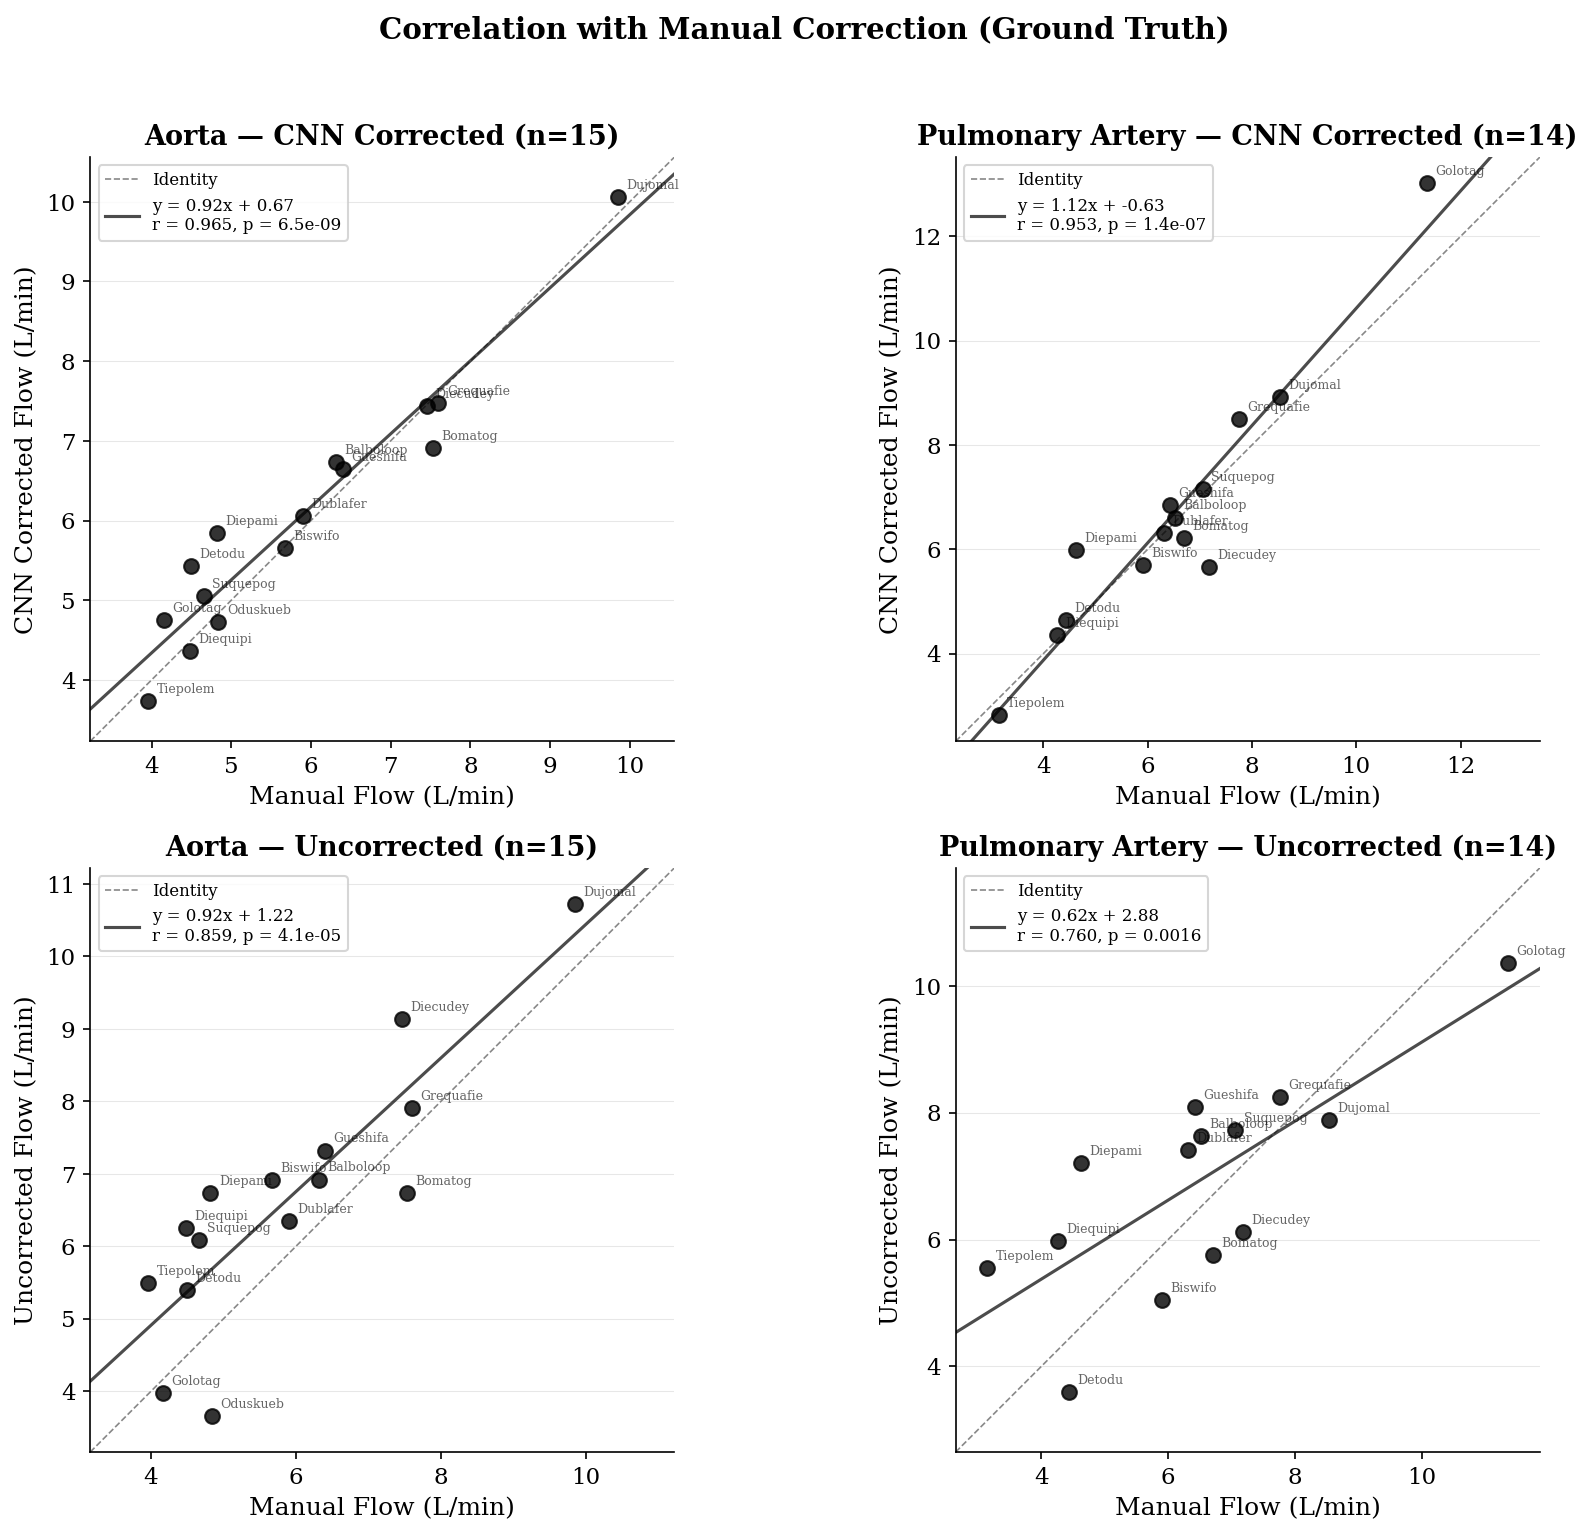

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for j, vessel in enumerate(VESSELS):
    vp = flow_pivot[flow_pivot["vessel"] == vessel].dropna(subset=["manual", "cnn", "uncorrected"])

    for i, method in enumerate(["cnn", "uncorrected"]):
        ax = axes[i, j]
        x = vp["manual"].values
        y = vp[method].values

        ax.scatter(x, y, c="black", edgecolors="black", s=50, alpha=0.8, zorder=3)

        for xi, yi, pt in zip(x, y, vp["patient"].values):
            ax.annotate(pt, (xi, yi), fontsize=6, alpha=0.6, xytext=(4, 4),
                        textcoords="offset points")

        all_vals = np.concatenate([x, y])
        lims = [all_vals.min() - 0.5, all_vals.max() + 0.5]
        ax.plot(lims, lims, "--", color="#888", linewidth=0.8, label="Identity")

        slope, intercept, r, p, se = sp_stats.linregress(x, y)
        xfit = np.linspace(lims[0], lims[1], 100)
        p_str = f"{p:.1e}" if p < 0.0001 else f"{p:.4f}"
        ax.plot(xfit, slope * xfit + intercept, "-", color="black",
                linewidth=1.5, alpha=0.7,
                label=f"y = {slope:.2f}x + {intercept:.2f}\nr = {r:.3f}, p = {p_str}")

        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect("equal")
        ax.set_xlabel("Manual Flow (L/min)")
        ax.set_ylabel(f"{LABELS[method]} Flow (L/min)")
        ax.set_title(f"{VESSEL_LABELS[vessel]} — {LABELS[method]} (n={len(vp)})", fontweight="bold")
        ax.legend(fontsize=8, loc="upper left")

fig.suptitle("Correlation with Manual Correction (Ground Truth)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 1c. Flow comparison: all three methods side by side

Grouped bar chart showing Manual, CNN Corrected, and Uncorrected flow for each patient.

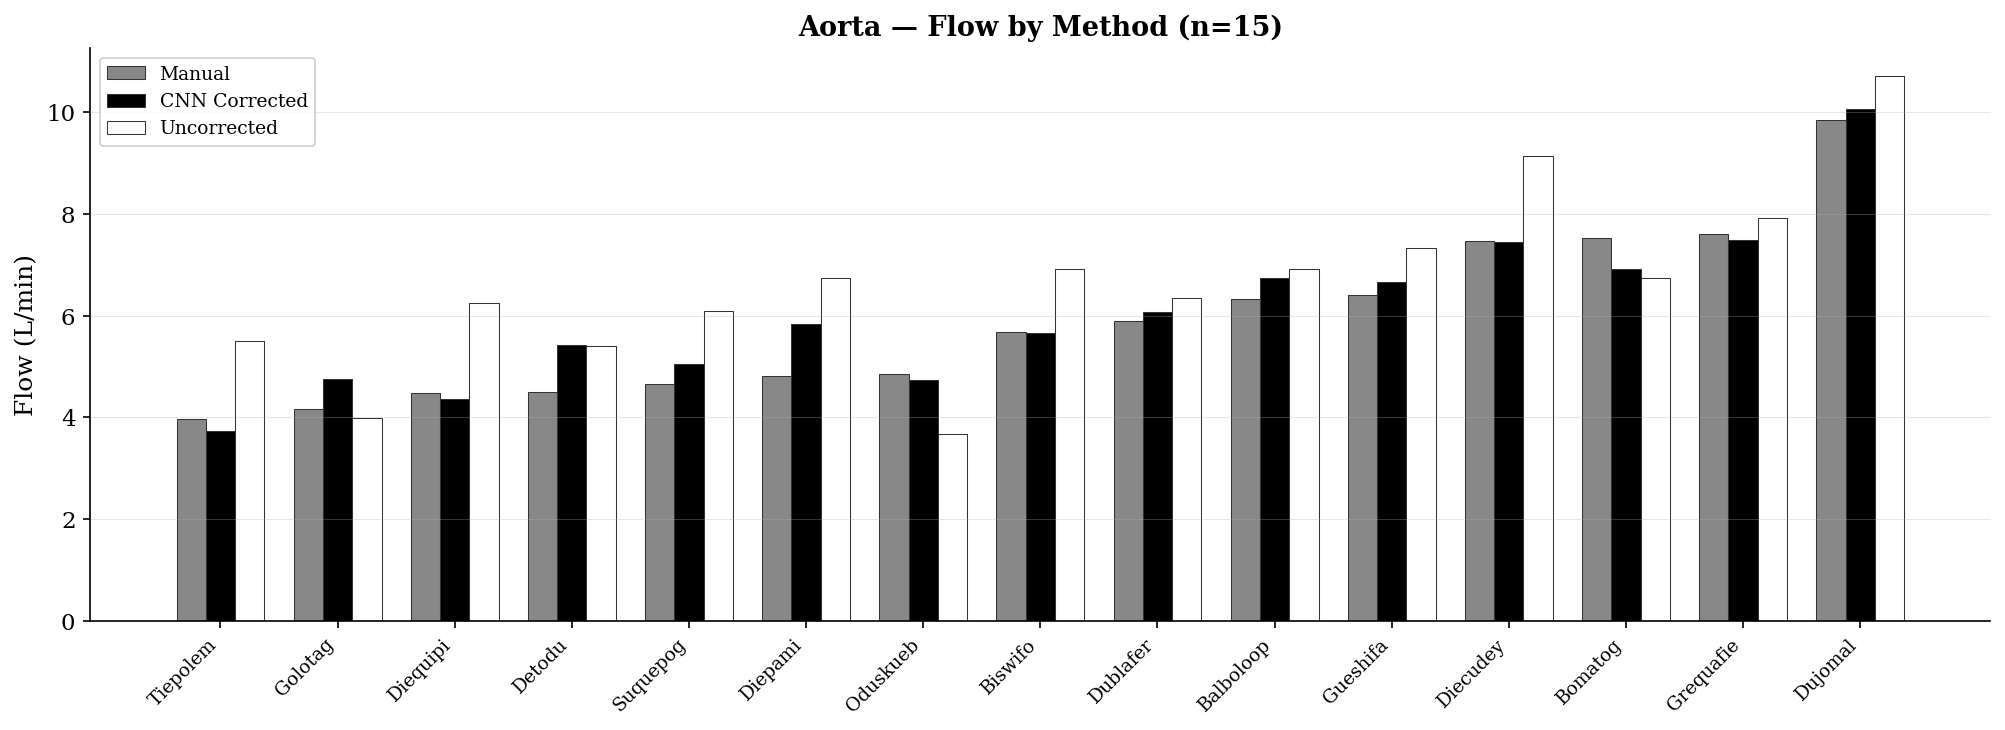

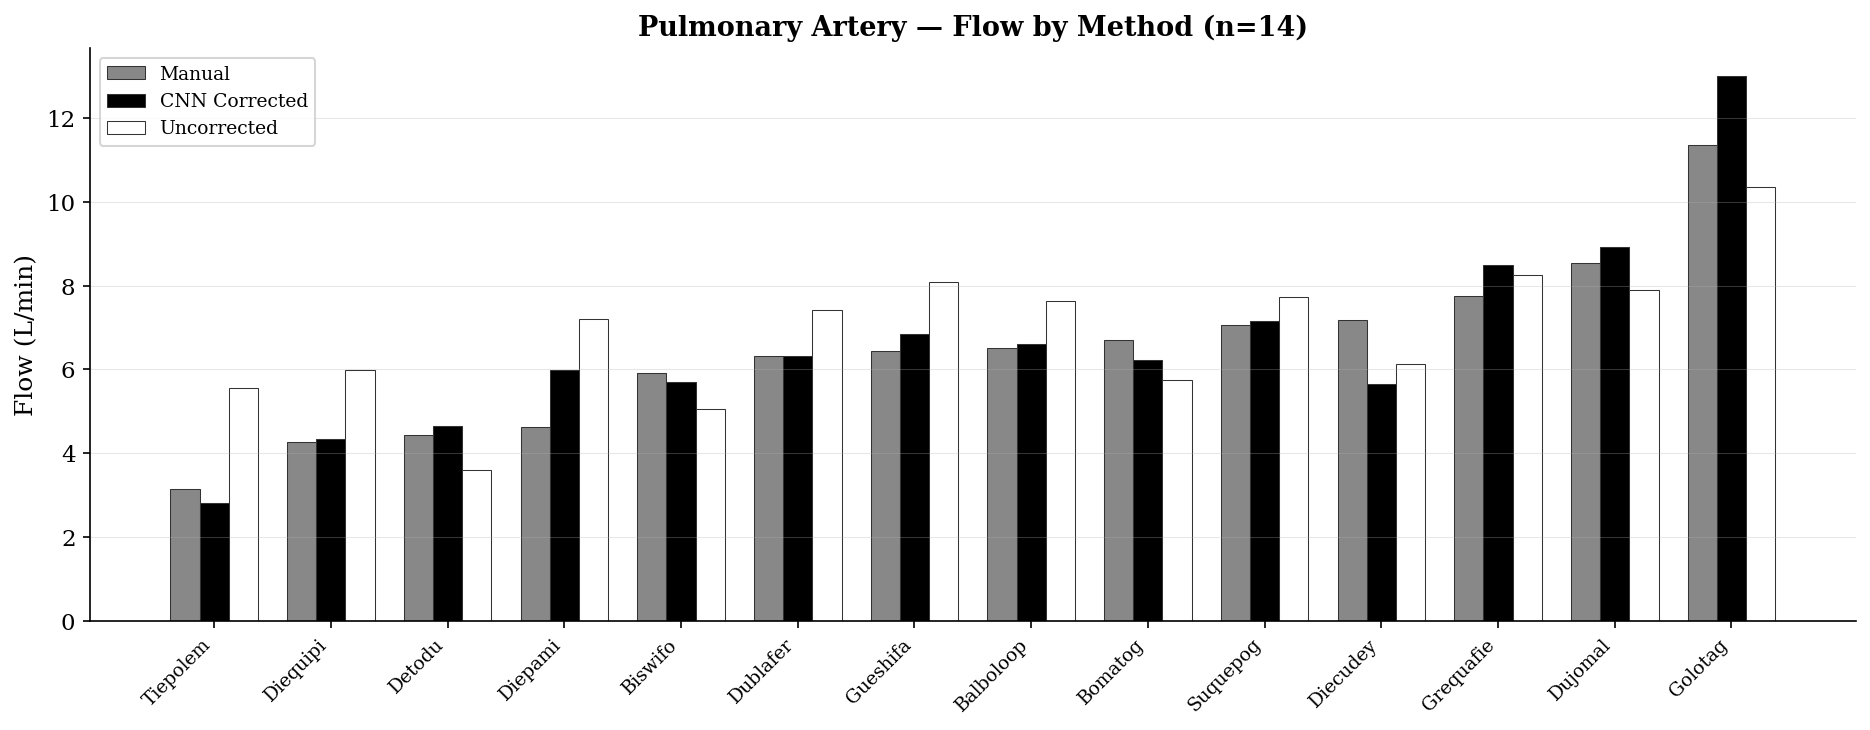

In [6]:
for vessel in VESSELS:
    vp = flow_pivot[flow_pivot["vessel"] == vessel].dropna(subset=["manual"]).sort_values("manual")
    patients = vp["patient"].values
    n = len(patients)
    x = np.arange(n)
    w = 0.25

    fig, ax = plt.subplots(figsize=(max(12, n * 0.9), 5))

    ax.bar(x - w, vp["manual"].values, w, color=COLORS["manual"],
           edgecolor="#333", linewidth=0.5, label=LABELS["manual"])
    ax.bar(x, vp["cnn"].values, w, color=COLORS["cnn"],
           edgecolor="#333", linewidth=0.5, label=LABELS["cnn"])
    ax.bar(x + w, vp["uncorrected"].values, w, color=COLORS["uncorrected"],
           edgecolor="#333", linewidth=0.5, label=LABELS["uncorrected"])

    ax.set_xticks(x)
    ax.set_xticklabels(patients, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Flow (L/min)")
    ax.set_title(f"{VESSEL_LABELS[vessel]} — Flow by Method (n={len(vp)})", fontweight="bold")
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

---

# 2. CNN correction reduces measurement error

### 2a. Absolute error comparison: CNN vs Uncorrected

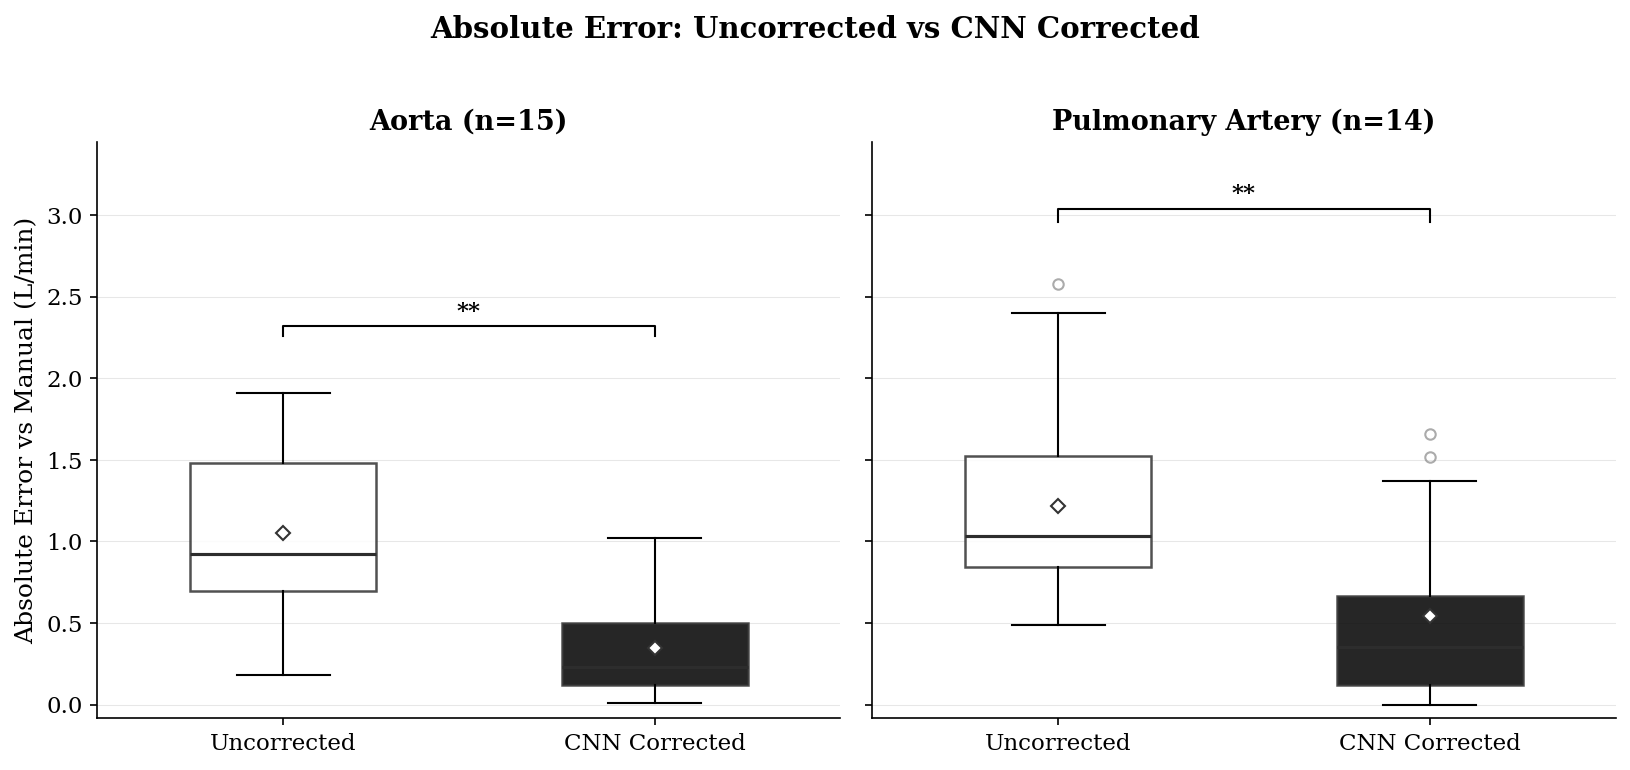

In [7]:
fig, axes = plt.subplots(1, len(VESSELS), figsize=(5.5 * len(VESSELS), 5), sharey=True)

for ax, vessel in zip(axes, VESSELS):
    vp = flow_pivot[flow_pivot["vessel"] == vessel].dropna(subset=["cnn_abs_error", "uncorrected_abs_error"])

    bp = ax.boxplot(
        [vp["uncorrected_abs_error"], vp["cnn_abs_error"]],
        positions=[0, 1], widths=0.5, **BOXPLOT_KW
    )
    color_boxes(bp, [COLORS["uncorrected"], COLORS["cnn"]])

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Uncorrected", "CNN Corrected"])
    ax.set_title(f"{VESSEL_LABELS[vessel]} (n={len(vp)})", fontweight="bold")

    sr = stats_results[
        (stats_results["vessel"] == vessel) &
        (stats_results["comparison"] == "Error reduction (|Uncorr| − |CNN|)")
    ]
    if len(sr):
        sig = sr["wilcoxon_sig"].values[0]
        if sig != "ns":
            ylim = ax.get_ylim()
            span = ylim[1] - ylim[0]
            y = ylim[1] + span * 0.15
            h = span * 0.03
            ax.plot([0, 0, 1, 1], [y - h, y, y, y - h], color="black", linewidth=1.0)
            ax.text(0.5, y + h * 0.3, sig, ha="center", va="bottom",
                    fontsize=11, fontweight="bold")
            ax.set_ylim(ylim[0], y + h * 5)

axes[0].set_ylabel("Absolute Error vs Manual (L/min)")
fig.suptitle("Absolute Error: Uncorrected vs CNN Corrected",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 2b. Paired error plots: per-patient error reduction

Each line connects one patient's absolute error under Uncorrected (left) to
CNN Corrected (right). Downward slope = error reduced by CNN correction.

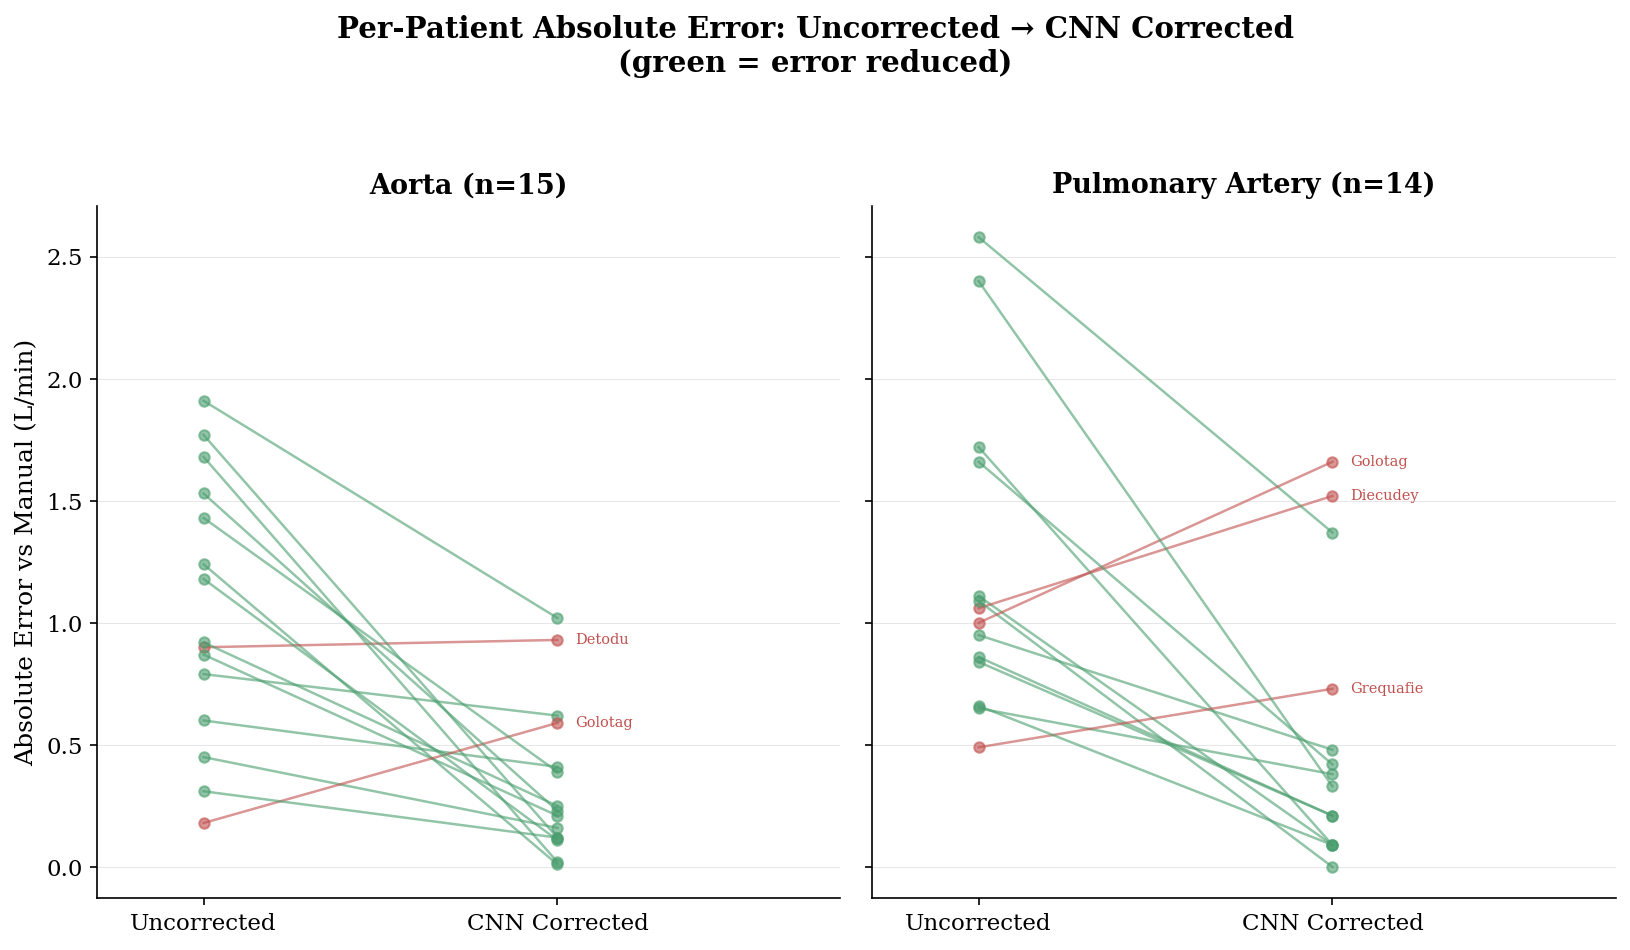

In [8]:
SLOPE_DOWN = "#4a9e6e"
SLOPE_UP = "#c0504d"

fig, axes = plt.subplots(1, len(VESSELS), figsize=(5.5 * len(VESSELS), 6), sharey=True)

for ax, vessel in zip(axes, VESSELS):
    vp = flow_pivot[flow_pivot["vessel"] == vessel].dropna(subset=["cnn_abs_error", "uncorrected_abs_error"])

    for _, row in vp.iterrows():
        color = SLOPE_DOWN if row["cnn_abs_error"] <= row["uncorrected_abs_error"] else SLOPE_UP
        ax.plot([0, 1], [row["uncorrected_abs_error"], row["cnn_abs_error"]],
                marker="o", color=color, alpha=0.6, linewidth=1.2, markersize=5)
        if row["cnn_abs_error"] > row["uncorrected_abs_error"]:
            ax.text(1.05, row["cnn_abs_error"], row["patient"],
                    fontsize=7, va="center", color=SLOPE_UP)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Uncorrected", "CNN Corrected"])
    ax.set_title(f"{VESSEL_LABELS[vessel]} (n={len(vp)})", fontweight="bold")
    ax.set_xlim(-0.3, 1.8)

axes[0].set_ylabel("Absolute Error vs Manual (L/min)")
fig.suptitle("Per-Patient Absolute Error: Uncorrected → CNN Corrected\n(green = error reduced)",
             fontsize=14, fontweight="bold", y=1.05)
fig.tight_layout()
plt.show()

### 2c. Error summary statistics

In [9]:
error_summary = []
for vessel in VESSELS:
    vp = flow_pivot[flow_pivot["vessel"] == vessel].dropna(subset=["cnn_abs_error", "uncorrected_abs_error"])
    for method in ["cnn", "uncorrected"]:
        ae = vp[f"{method}_abs_error"]
        err = vp[f"{method}_error"]
        error_summary.append({
            "vessel": vessel,
            "method": LABELS[method],
            "bias": err.mean(),
            "bias_std": err.std(),
            "mae": ae.mean(),
            "rmse": np.sqrt((err ** 2).mean()),
            "max_abs_error": ae.max(),
            "n": len(vp),
        })

error_summary_df = pd.DataFrame(error_summary)
print("Error summary (vs Manual ground truth):")
display(error_summary_df.round(3))

Error summary (vs Manual ground truth):


,vessel,method,bias,bias_std,mae,rmse,max_abs_error,n
0,Ao,CNN Corrected,0.182,0.438,0.346,0.461,1.02,15
1,Ao,Uncorrected,0.764,0.922,1.051,1.173,1.91,15
2,PA,CNN Corrected,0.179,0.775,0.541,0.768,1.66,14
3,PA,Uncorrected,0.454,1.337,1.219,1.366,2.58,14


---

# 3. Supporting analyses

### 3a. Qp/Qs ratio analysis

Qp/Qs = PA flow / Ao flow. A clinically important derived metric.
In normal subjects, Qp/Qs ≈ 1.0.

In [10]:
ao_pivot = flow_pivot[flow_pivot["vessel"] == "Ao"][["patient", "manual", "cnn", "uncorrected"]].rename(
    columns={"manual": "ao_manual", "cnn": "ao_cnn", "uncorrected": "ao_uncorrected"}
)
pa_pivot = flow_pivot[flow_pivot["vessel"] == "PA"][["patient", "manual", "cnn", "uncorrected"]].rename(
    columns={"manual": "pa_manual", "cnn": "pa_cnn", "uncorrected": "pa_uncorrected"}
)
qpqs = ao_pivot.merge(pa_pivot, on="patient", how="inner")

qpqs["qpqs_manual"] = qpqs["pa_manual"] / qpqs["ao_manual"]
qpqs["qpqs_cnn"] = qpqs["pa_cnn"] / qpqs["ao_cnn"]
qpqs["qpqs_uncorrected"] = qpqs["pa_uncorrected"] / qpqs["ao_uncorrected"]

print(f"Qp/Qs analysis: {len(qpqs)} patients with both Ao and PA data\n")

print("Qp/Qs summary:")
for method, label in [("manual", "Manual"), ("cnn", "CNN Corrected"), ("uncorrected", "Uncorrected")]:
    col = f"qpqs_{method}"
    vals = qpqs[col]
    print(f"  {label:16s}: mean={vals.mean():.3f}, std={vals.std():.3f}, "
          f"median={vals.median():.3f}, range=[{vals.min():.3f}, {vals.max():.3f}]")

print("\nQp/Qs per patient:")
display(qpqs[["patient", "qpqs_manual", "qpqs_cnn", "qpqs_uncorrected"]]
        .sort_values("qpqs_manual").round(3))

Qp/Qs analysis: 14 patients with both Ao and PA data

Qp/Qs summary:
  Manual          : mean=1.131, std=0.489, median=0.996, range=[0.795, 2.731]
  CNN Corrected   : mean=1.110, std=0.497, median=1.002, range=[0.756, 2.741]
  Uncorrected     : mean=1.070, std=0.482, median=1.027, range=[0.667, 2.603]

Qp/Qs per patient:


method,patient,qpqs_manual,qpqs_cnn,qpqs_uncorrected
13,Tiepolem,0.795,0.756,1.011
8,Dujomal,0.867,0.887,0.736
2,Bomatog,0.890,0.900,0.853
6,Diequipi,0.951,0.998,0.957
5,Diepami,0.959,1.026,1.070
4,Diecudey,0.962,0.761,0.670
3,Detodu,0.987,0.856,0.667
11,Gueshifa,1.005,1.030,1.105
10,Grequafie,1.021,1.135,1.043
0,Balboloop,1.032,0.982,1.103


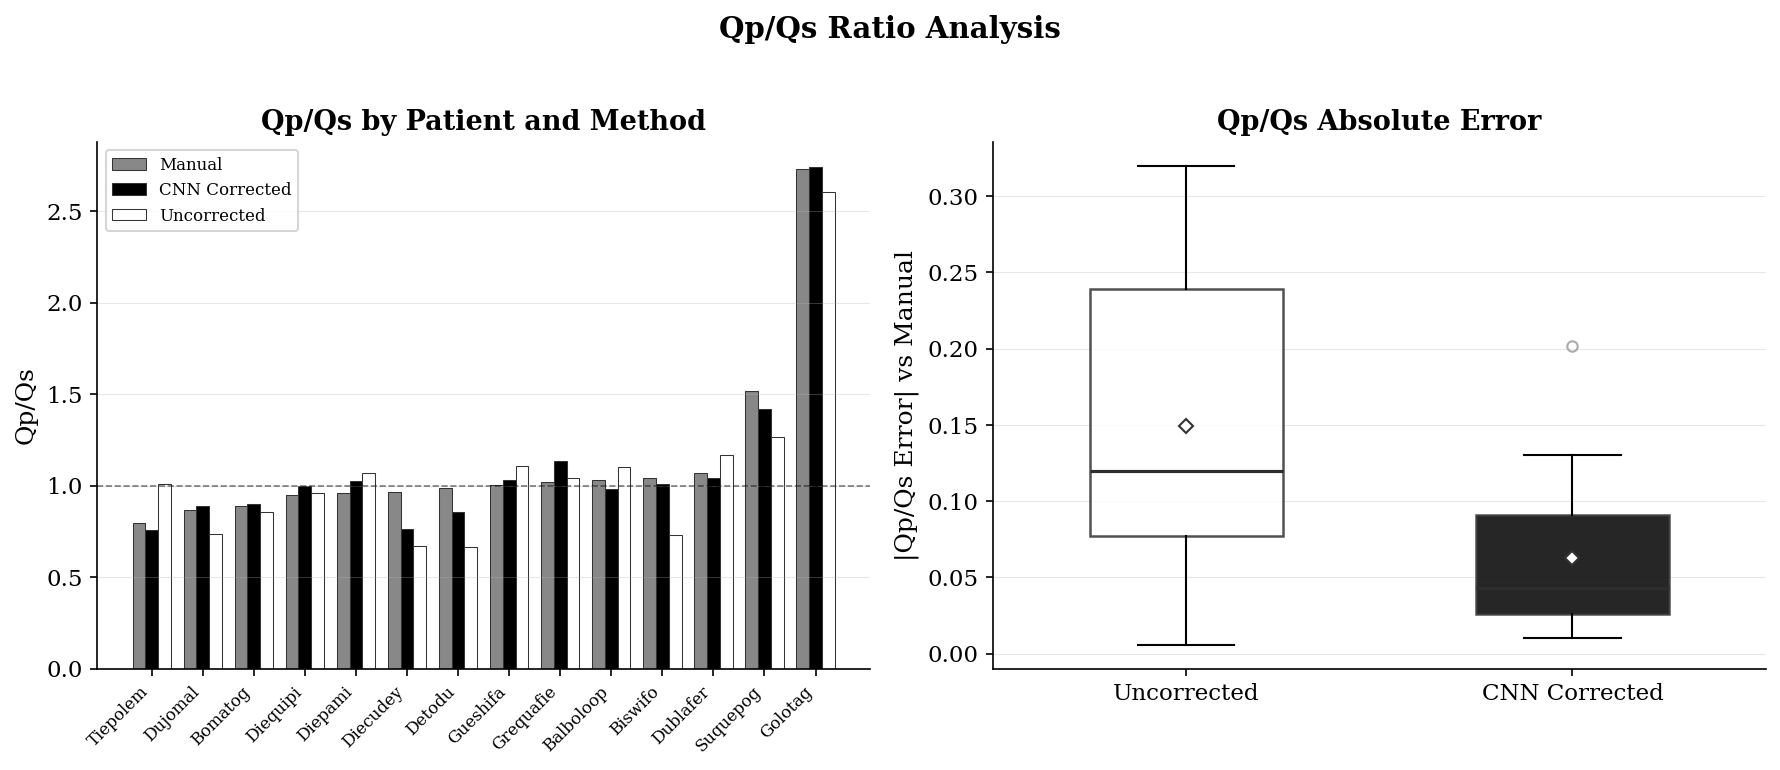


Qp/Qs MAE — CNN: 0.063, Uncorrected: 0.149
Wilcoxon signed-rank (|Uncorr error| − |CNN error|): p = 0.0067 **


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart of Qp/Qs by method
ax = axes[0]
qpqs_sorted = qpqs.sort_values("qpqs_manual")
patients = qpqs_sorted["patient"].values
n = len(patients)
x = np.arange(n)
w = 0.25

ax.bar(x - w, qpqs_sorted["qpqs_manual"].values, w, color=COLORS["manual"],
       edgecolor="#333", linewidth=0.5, label="Manual")
ax.bar(x, qpqs_sorted["qpqs_cnn"].values, w, color=COLORS["cnn"],
       edgecolor="#333", linewidth=0.5, label="CNN Corrected")
ax.bar(x + w, qpqs_sorted["qpqs_uncorrected"].values, w, color=COLORS["uncorrected"],
       edgecolor="#333", linewidth=0.5, label="Uncorrected")

ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(patients, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Qp/Qs")
ax.set_title("Qp/Qs by Patient and Method", fontweight="bold")
ax.legend(fontsize=8)

# Qp/Qs error: CNN vs Uncorrected (reference = manual Qp/Qs)
ax = axes[1]
qpqs["qpqs_cnn_error"] = (qpqs["qpqs_cnn"] - qpqs["qpqs_manual"]).abs()
qpqs["qpqs_uncorrected_error"] = (qpqs["qpqs_uncorrected"] - qpqs["qpqs_manual"]).abs()

bp = ax.boxplot(
    [qpqs["qpqs_uncorrected_error"], qpqs["qpqs_cnn_error"]],
    positions=[0, 1], widths=0.5, **BOXPLOT_KW
)
color_boxes(bp, [COLORS["uncorrected"], COLORS["cnn"]])
ax.set_xticks([0, 1])
ax.set_xticklabels(["Uncorrected", "CNN Corrected"])
ax.set_ylabel("|Qp/Qs Error| vs Manual")
ax.set_title("Qp/Qs Absolute Error", fontweight="bold")

fig.suptitle("Qp/Qs Ratio Analysis", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

print(f"\nQp/Qs MAE — CNN: {qpqs['qpqs_cnn_error'].mean():.3f}, "
      f"Uncorrected: {qpqs['qpqs_uncorrected_error'].mean():.3f}")

if len(qpqs) >= 5:
    diff = qpqs["qpqs_uncorrected_error"].values - qpqs["qpqs_cnn_error"].values
    w_stat, w_p = sp_stats.wilcoxon(diff)
    print(f"Wilcoxon signed-rank (|Uncorr error| − |CNN error|): p = {w_p:.4f} {_sig(w_p)}")

### 3a.1 Qp/Qs Internal Consistency — Non-shunt Patients (Bland-Altman)

In patients without shunts, Qp and Qs should be approximately equal.
We assess this internal consistency by constructing **Bland-Altman plots
of Qp vs. Qs** for each measurement method, following the approach of
[Hsiao et al. (2011)](https://doi.org/10.1007/s00247-010-1932-z).

Patients with known shunts (PAPVR, PDA, VSD) or Fontan physiology are excluded.

Non-shunt patients for Qp/Qs consistency analysis: 11


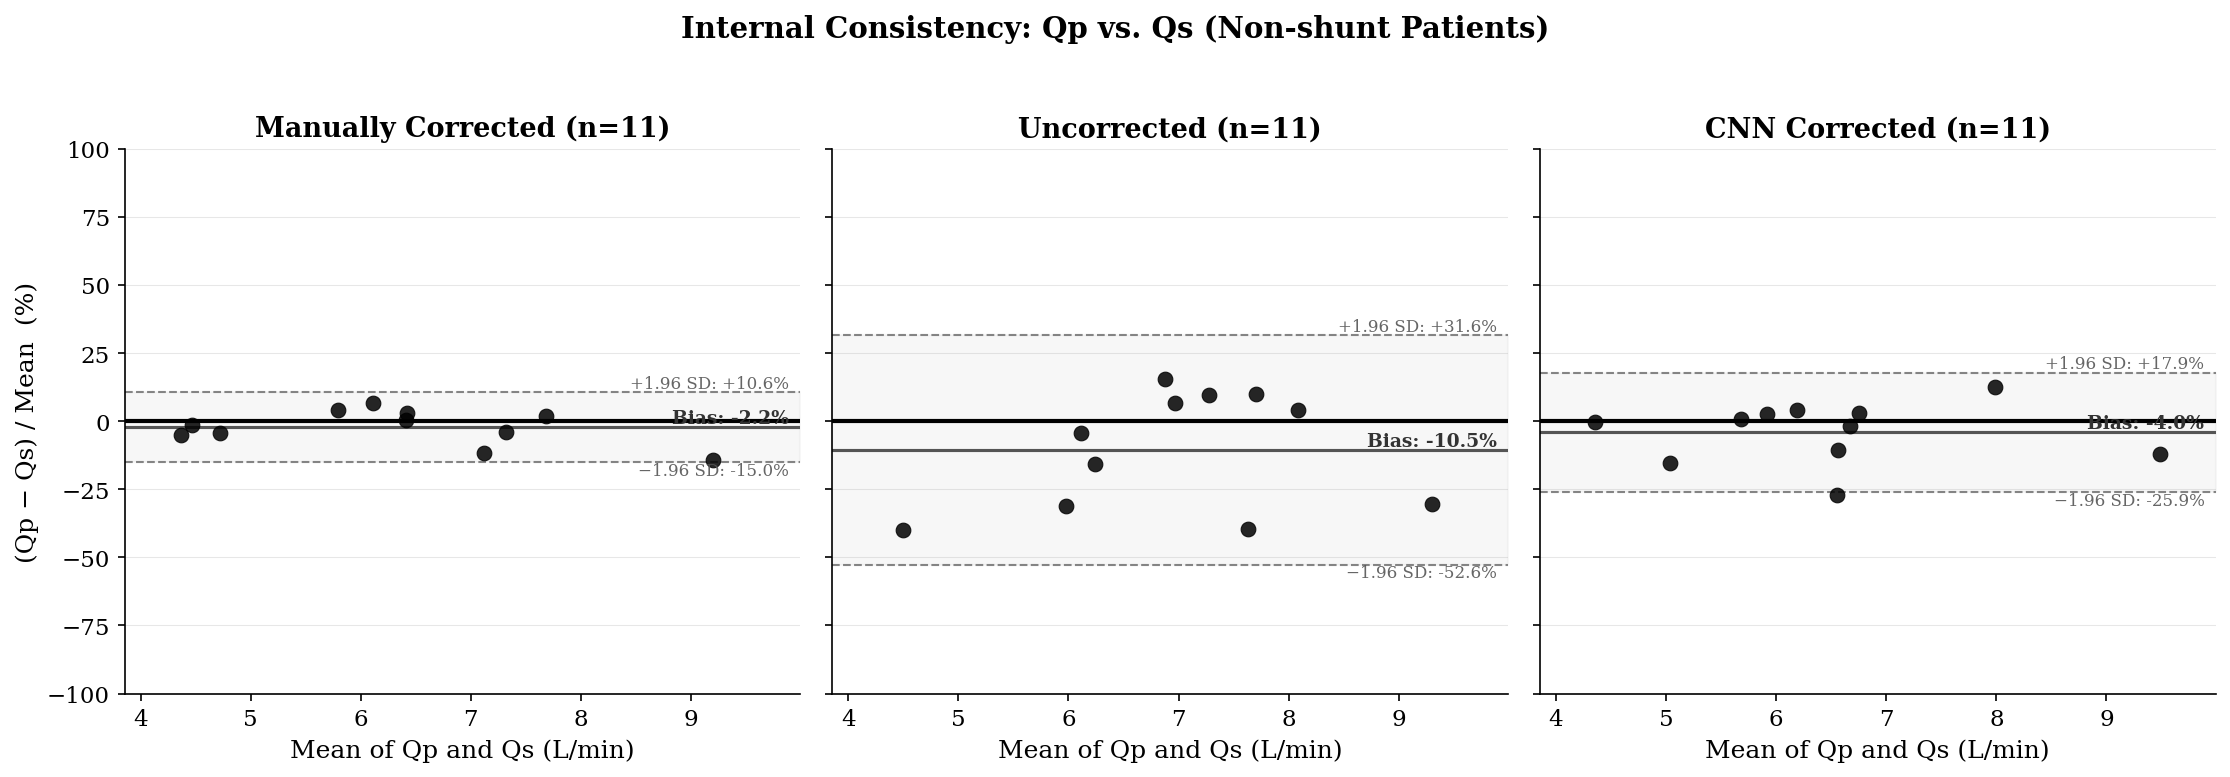


Qp−Qs Bland-Altman summary (non-shunt patients, % difference):
Method                 n    Bias%      SD%  LoA lower%  LoA upper%
Manually Corrected    11    -2.15     6.53      -14.95      +10.65
Uncorrected           11   -10.48    21.49      -52.60      +31.64
CNN Corrected         11    -4.01    11.19      -25.95      +17.92


In [12]:
SHUNT_PATIENTS = {"Golotag", "Tiepolem", "Oduskueb", "Suquepog"}
qpqs_ns = qpqs[~qpqs["patient"].isin(SHUNT_PATIENTS)].copy()
print(f"Non-shunt patients for Qp/Qs consistency analysis: {len(qpqs_ns)}")

methods_ordered = ["uncorrected", "cnn", "manual"]
method_titles = {"manual": "Manually Corrected", "uncorrected": "Uncorrected", "cnn": "CNN Corrected"}

all_means, all_pct_diffs = [], []
ba_ns_data = {}
for method in methods_ordered:
    ao_col, pa_col = f"ao_{method}", f"pa_{method}"
    sub = qpqs_ns[[ao_col, pa_col]].dropna()
    qs, qp = sub[ao_col].values, sub[pa_col].values
    mean_flow = (qp + qs) / 2
    pct_diff = (qp - qs) / mean_flow * 100
    ba_ns_data[method] = (mean_flow, pct_diff)
    all_means.extend(mean_flow)
    all_pct_diffs.extend(pct_diff)

x_lo, x_hi = min(all_means) - 0.5, max(all_means) + 0.5
y_lo, y_hi = -100, 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, method in zip(axes, methods_ordered):
    mean_flow, pct_diff = ba_ns_data[method]
    bias = pct_diff.mean()
    sd = pct_diff.std(ddof=1)
    loa_lo, loa_hi = bias - 1.96 * sd, bias + 1.96 * sd

    color = COLORS.get(method, "#888")
    ax.scatter(mean_flow, pct_diff, c="black", edgecolors="black",
               linewidths=0.5, s=50, zorder=3, alpha=0.85)

    ax.axhline(bias, color="#555", linewidth=1.5, linestyle="-")
    ax.axhline(loa_lo, color="#555", linewidth=1, linestyle="--", alpha=0.7)
    ax.axhline(loa_hi, color="#555", linewidth=1, linestyle="--", alpha=0.7)
    ax.axhline(0, color="black", linewidth=2.0, alpha=1.0)

    ax.fill_between([x_lo, x_hi], loa_lo, loa_hi, color="#cccccc", alpha=0.15)

    ax.text(x_hi - 0.1, bias, f"Bias: {bias:+.1f}%", ha="right", va="bottom",
            fontsize=9, color="#333", fontweight="bold")
    ax.text(x_hi - 0.1, loa_hi, f"+1.96 SD: {loa_hi:+.1f}%", ha="right", va="bottom",
            fontsize=8, color="#555", alpha=0.9)
    ax.text(x_hi - 0.1, loa_lo, f"−1.96 SD: {loa_lo:+.1f}%", ha="right", va="top",
            fontsize=8, color="#555", alpha=0.9)

    ax.set_title(method_titles[method], fontweight="bold")
    ax.set_xlabel("Mean of Qp and Qs (L/min)")

axes[0].set_ylabel("(Qp − Qs) / Mean  (%)")
axes[0].set_xlim(x_lo, x_hi)
axes[0].set_ylim(y_lo, y_hi)

n_ns = len(qpqs_ns)
fig.suptitle(f"Internal Consistency: Qp vs. Qs (Non-shunt Patients, n={n_ns})",
             fontsize=14, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()

print("\nQp−Qs Bland-Altman summary (non-shunt patients, % difference):")
print(f"{'Method':<20s} {'n':>3s} {'Bias%':>8s} {'SD%':>8s} {'LoA lower%':>11s} {'LoA upper%':>11s}")
for method in methods_ordered:
    mean_flow, pct_diff = ba_ns_data[method]
    n = len(pct_diff)
    bias = pct_diff.mean()
    sd = pct_diff.std(ddof=1)
    print(f"{method_titles[method]:<20s} {n:3d} {bias:+8.2f} {sd:8.2f} {bias-1.96*sd:+11.2f} {bias+1.96*sd:+11.2f}")

In [13]:
print("Statistical tests on |Qp−Qs| % difference (non-shunt patients):\n")

abs_diffs = {}
for method in methods_ordered:
    _, pct_diff = ba_ns_data[method]
    abs_diffs[method] = np.abs(pct_diff)
    print(f"{method_titles[method]:<20s}  |Qp−Qs|% mean={abs_diffs[method].mean():.2f}%, "
          f"median={np.median(abs_diffs[method]):.2f}%")

comparisons = [
    ("uncorrected", "cnn", "Uncorrected vs CNN"),
    ("uncorrected", "manual", "Uncorrected vs Manual"),
    ("cnn", "manual", "CNN vs Manual"),
]

print(f"\n{'Comparison':<30s} {'Wilcoxon p':>12s} {'Sig':>5s}")
for m1, m2, label in comparisons:
    d = abs_diffs[m1] - abs_diffs[m2]
    if np.any(d != 0):
        w_stat, w_p = sp_stats.wilcoxon(d)
    else:
        w_p = 1.0
    print(f"{label:<30s} {w_p:12.4f} {_sig(w_p):>5s}")

print("\nBrown-Forsythe test (equality of variance of Qp−Qs %):")
diffs_list = [ba_ns_data[m][1] for m in methods_ordered]
bf_stat, bf_p = sp_stats.levene(*diffs_list, center="median")
print(f"  F = {bf_stat:.3f}, p = {bf_p:.4f} {_sig(bf_p)}")

for m1, m2, label in [("uncorrected", "cnn", "Uncorrected vs CNN"),
                        ("uncorrected", "manual", "Uncorrected vs Manual")]:
    bf_s, bf_pval = sp_stats.levene(ba_ns_data[m1][1], ba_ns_data[m2][1], center="median")
    print(f"  {label}: F = {bf_s:.3f}, p = {bf_pval:.4f} {_sig(bf_pval)}")

Statistical tests on |Qp−Qs| % difference (non-shunt patients):

Manually Corrected    |Qp−Qs|% mean=5.19%, median=4.15%
Uncorrected           |Qp−Qs|% mean=18.86%, median=15.41%
CNN Corrected         |Qp−Qs|% mean=8.21%, median=4.20%

Comparison                       Wilcoxon p   Sig
Uncorrected vs CNN                   0.0137     *
Uncorrected vs Manual                0.0020    **
CNN vs Manual                        0.8984    ns

Brown-Forsythe test (equality of variance of Qp−Qs %):
  F = 7.728, p = 0.0020 **
  Uncorrected vs CNN: F = 5.968, p = 0.0240 *
  Uncorrected vs Manual: F = 13.852, p = 0.0013 **


### 3b. Signed error distribution (bias direction)

Histogram of signed errors for CNN and Uncorrected, showing whether
each method tends to over- or under-estimate flow.

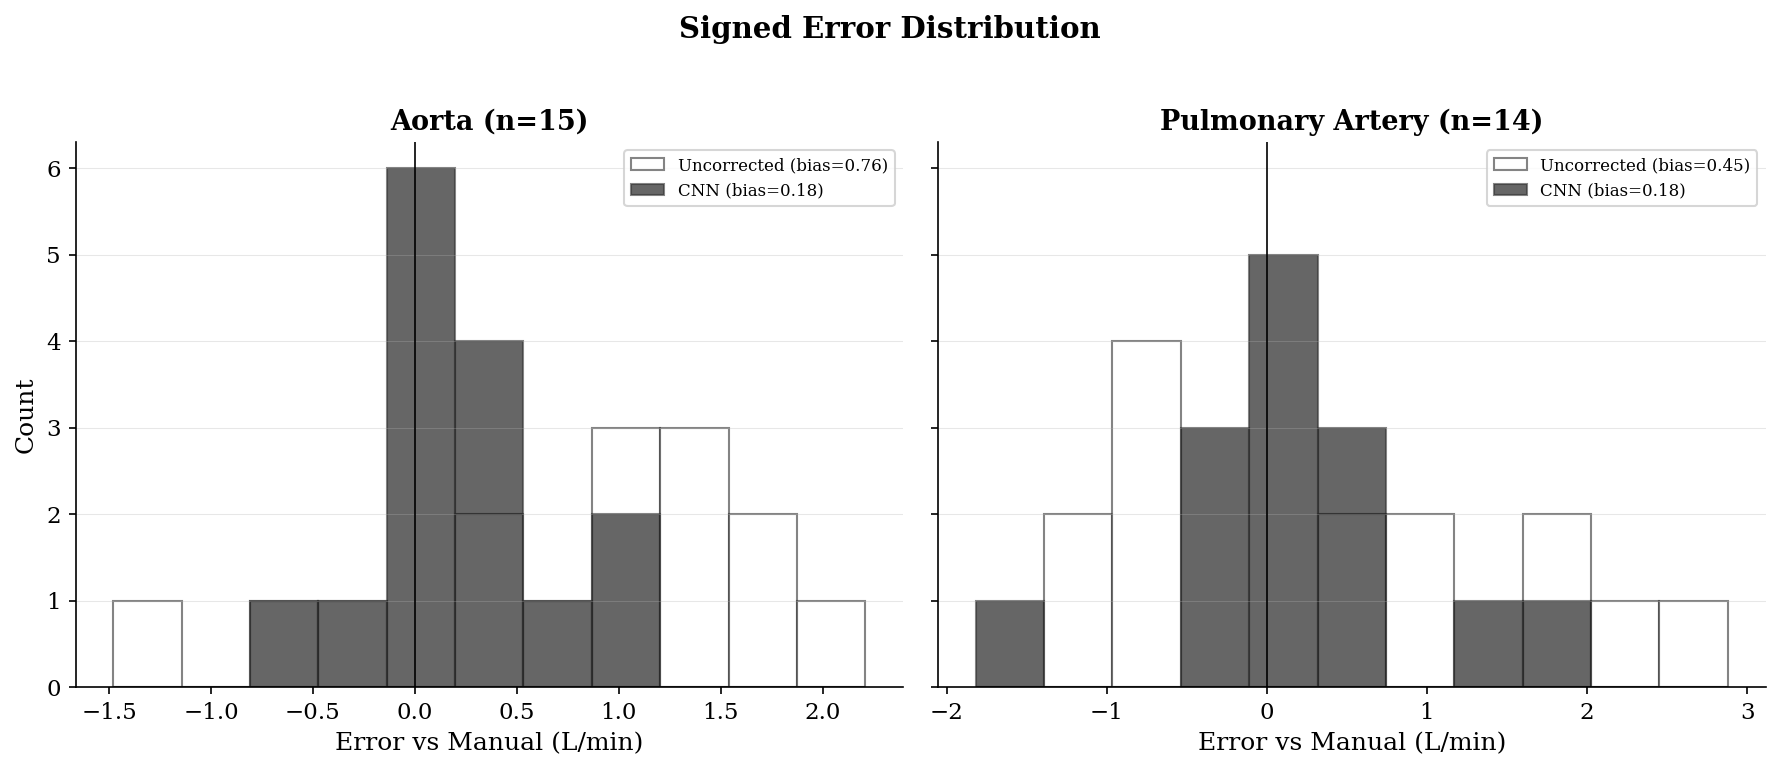

In [14]:
fig, axes = plt.subplots(1, len(VESSELS), figsize=(6 * len(VESSELS), 5), sharey=True)

for ax, vessel in zip(axes, VESSELS):
    vp = flow_pivot[flow_pivot["vessel"] == vessel].dropna(subset=["cnn_error", "uncorrected_error"])

    bins = np.linspace(
        min(vp["cnn_error"].min(), vp["uncorrected_error"].min()) - 0.3,
        max(vp["cnn_error"].max(), vp["uncorrected_error"].max()) + 0.3,
        12
    )

    ax.hist(vp["uncorrected_error"], bins=bins, alpha=0.6, color=COLORS["uncorrected"],
            edgecolor="#333", label=f"Uncorrected (bias={vp['uncorrected_error'].mean():.2f})")
    ax.hist(vp["cnn_error"], bins=bins, alpha=0.6, color=COLORS["cnn"],
            edgecolor="#333", label=f"CNN (bias={vp['cnn_error'].mean():.2f})")

    ax.axvline(0, color="black", linewidth=0.8, linestyle="-")
    ax.set_xlabel("Error vs Manual (L/min)")
    ax.set_title(f"{VESSEL_LABELS[vessel]} (n={len(vp)})", fontweight="bold")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Count")
fig.suptitle("Signed Error Distribution",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 3c. Error heatmap by patient

Rows = patients, columns = method × vessel. Color encodes signed error
(blue = underestimate, red = overestimate, white = close to manual).

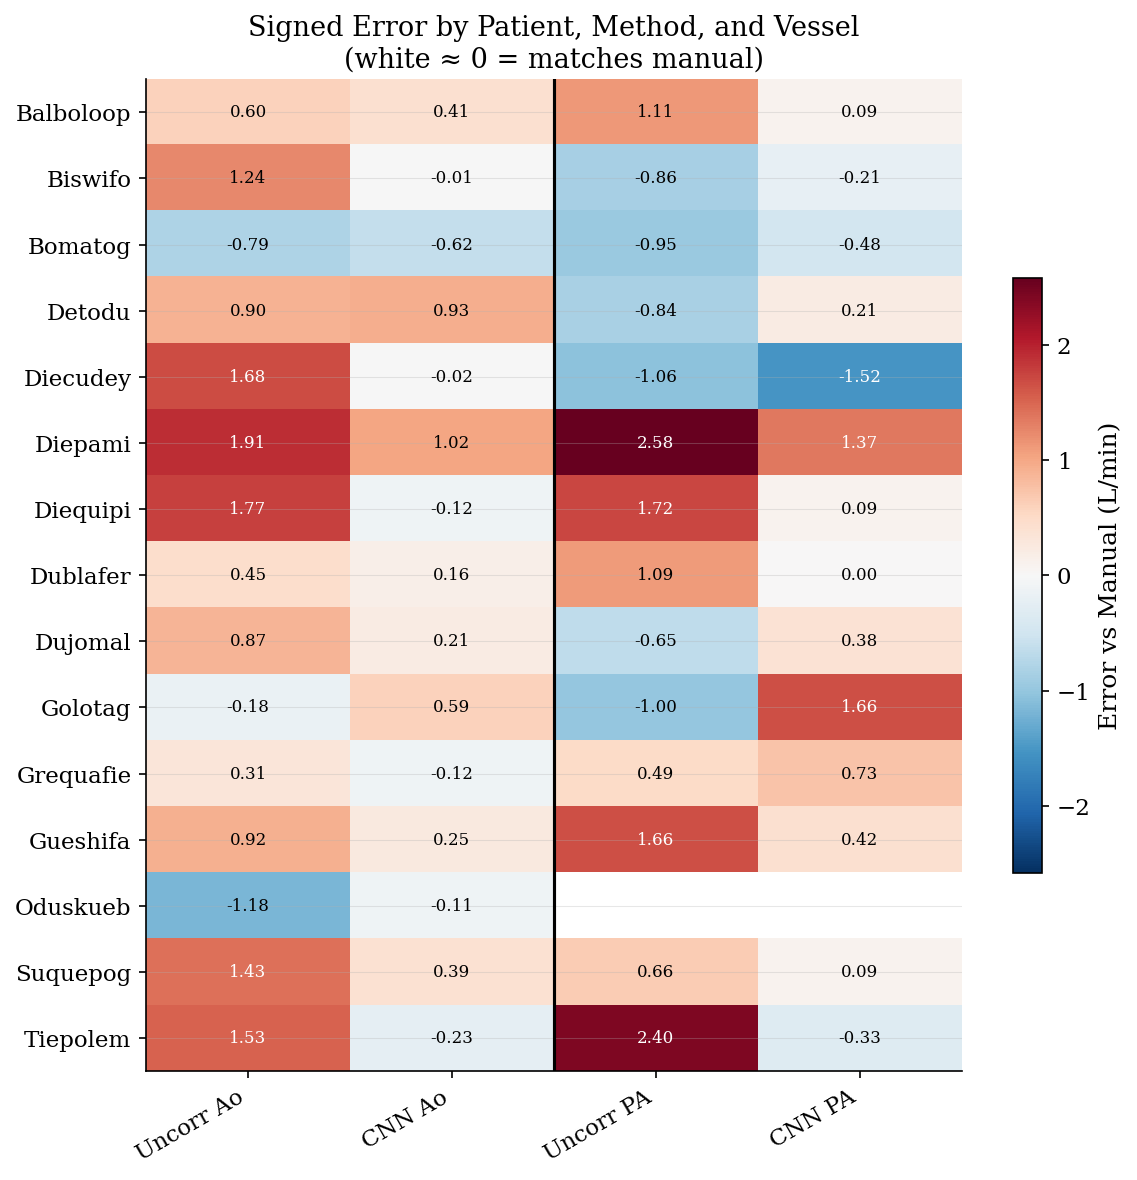

In [15]:
from matplotlib.colors import TwoSlopeNorm

heatmap_data = flow_pivot.pivot_table(
    index="patient",
    columns="vessel",
    values=["cnn_error", "uncorrected_error"],
).sort_index()

heatmap_data.columns = [f"{m.replace('_error', '')} {v}" for m, v in heatmap_data.columns]
col_order = ["uncorrected Ao", "cnn Ao", "uncorrected PA", "cnn PA"]
col_order = [c for c in col_order if c in heatmap_data.columns]
heatmap_data = heatmap_data[col_order]

max_abs = max(heatmap_data.abs().max().max(), 0.1)
norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(heatmap_data.values, cmap="RdBu_r", norm=norm, aspect="auto")

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels([c.replace("uncorrected", "Uncorr").replace("cnn", "CNN")
                     for c in heatmap_data.columns], rotation=30, ha="right")
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(val) > max_abs * 0.5 else "black")

fig.colorbar(im, ax=ax, shrink=0.6, label="Error vs Manual (L/min)")
ax.set_title("Signed Error by Patient, Method, and Vessel\n(white ≈ 0 = matches manual)", fontsize=13)

ax.axvline(1.5, color="black", linewidth=1.5)

fig.tight_layout()
plt.show()

### 3d. Full statistical results table

In [16]:
display_cols = [
    "vessel", "comparison", "n", "bias", "bias_std",
    "loa_lower", "loa_upper", "mae", "rmse",
    "pearson_r", "normality", "wilcoxon_p", "wilcoxon_sig",
    "ttest_p", "ttest_sig"
]
display(stats_results[display_cols].round(4))

,vessel,comparison,n,bias,bias_std,loa_lower,loa_upper,mae,rmse,pearson_r,normality,wilcoxon_p,wilcoxon_sig,ttest_p,ttest_sig
0,Ao,CNN Corrected vs Manual,15,0.1820,0.4233,-0.6477,1.0117,0.3460,0.4608,0.9647,yes,0.1876,ns,0.1300,ns
1,Ao,Uncorrected vs Manual,15,0.7640,0.8904,-0.9812,2.5092,1.0507,1.1732,0.8591,yes,0.0084,**,0.0063,**
2,Ao,Error reduction (|Uncorr| − |CNN|),15,0.7047,0.6050,NaN,NaN,NaN,NaN,NaN,yes,0.0012,**,0.0007,***
3,PA,CNN Corrected vs Manual,14,0.1786,0.7465,-1.2846,1.6417,0.5414,0.7676,0.9531,yes,0.3276,ns,0.4041,ns
4,PA,Uncorrected vs Manual,14,0.4536,1.2884,-2.0717,2.9789,1.2193,1.3659,0.7600,yes,0.2166,ns,0.2266,ns
5,PA,Error reduction (|Uncorr| − |CNN|),14,0.6779,0.7503,NaN,NaN,NaN,NaN,NaN,yes,0.0085,**,0.0062,**
